# ENCS5342 — Assignment #1
## Arabic Stemming, Lemmatization, and Regular Expressions

| | |
|---|---|
| **Course** | ENCS5342 — Information Retrieval with Applications of NLP |
| **Instructor** | Dr. Ahmed I. A. Shawahna — Birzeit University |
| **Semester** | Second Semester 2025–2026 |


| | Name | ID | Section |
|---|---|---|---|
| **Student 1** | Hala Sabobeh | 1220322 | Sec2 | 
| **Student 2** | Nour Omari | 1221212 | Sec3| 

---
## Before Starting

### Corpus: UN Parallel Corpus (UNCorpus)

This assignment uses the **United Nations General Assembly Resolutions Corpus (UNCorpus)**, a corpus of UN General Assembly resolutions. The UNCorpus is a six-language parallel text in Arabic, Chinese, English, French, Russian, and Spanish. The following paper describes the corpus:

> Rafalovitch, A. & Dale, R. (2009). *United Nations General Assembly Resolutions: A Six-Language Parallel Corpus.* Proceedings of MT Summit XII, Ottawa, Canada.  
> URL: http://web.science.mq.edu.au/~rdale/publications/papers/2009/MTS-2009-Rafalovitch.pdf

The portion of the UNCorpus used in this assignment is the file **`uncorpora_plain_20090831.tmx`**. This file is referred to as the **UNCorpus** throughout this document. It is stored in TMX format (Translation Memory eXchange), an XML-based standard for parallel corpora.

> **You can download the file from the following link:** https://drive.google.com/file/d/1AS1m3uzDL6B49xN4R7k2WWqOyRxP3QpI/view?usp=sharing  
> **Before running any cells:** place `uncorpora_plain_20090831.tmx` in the **same directory** as this notebook.

### Assignment Structure



---
## Setup — Run This Cell First

This cell installs all required Python packages and loads the UNCorpus into memory. All subsequent cells depend on variables defined here. **Run this cell before any other.**

In [38]:
import re, os, sys, subprocess
from collections import Counter, defaultdict

# Install required packages
subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'nltk', 'tashaphyne', 'sinatools', 'matplotlib',
     '-q', '--disable-pip-version-check'],
    capture_output=True
)

import nltk
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
nltk.download('punkt', quiet=True)

# ── Load corpus ───────────────────────────────────────────────────
CORPUS_FILE = 'uncorpora_plain_20090831.tmx'

if not os.path.exists(CORPUS_FILE):
    print(f'ERROR: corpus file not found — {CORPUS_FILE}')
    print('Place the .tmx file in the same directory as this notebook.')
else:
    size_mb = os.path.getsize(CORPUS_FILE) / (1024 * 1024)
    with open(CORPUS_FILE, 'r', encoding='utf-8', errors='replace') as f:
        content   = f.read()
        f.seek(0)
        all_lines = f.readlines()
    print(f'Corpus file : {CORPUS_FILE}  ({size_mb:.1f} MB)')
    print(f'Lines loaded: {len(all_lines):,}')
    print('Setup complete.')


Corpus file : uncorpora_plain_20090831.tmx  (155.6 MB)
Lines loaded: 1,501,316
Setup complete.


---
# Section A: Regular Expressions (70 points)

All answers in this section must be obtained using **Python and the `re` module**. Use `re.search()`, `re.findall()`, or `re.sub()` as appropriate.

**How to present your answers:** Run the code cell for each question so that the output is visible beneath it, then write your written answer or discussion in the Markdown cell that follows.


---
### A0 (0 pt) — Worked Example: Lines Mentioning "Human Rights"

**Task:** Ignoring letter case, how many **lines** in the UNCorpus mention the phrase *Human Rights*?

This question is solved for you as a worked example illustrating the expected format: a code cell followed by a Markdown cell with the written answer.


In [39]:
# A0 — Worked example
count_hr = sum(1 for line in all_lines
               if re.search(r'human rights', line, re.IGNORECASE))
print(f'{count_hr:,} lines mention "Human Rights" (case-insensitive).')


5,664 lines mention "Human Rights" (case-insensitive).


**Answer:** 5,664 lines of text mention the phrase *Human Rights*.


---
### A1 (5 pt) — XML Structure of the UNCorpus

**Task:** Use Python and regular expressions to investigate and describe the XML structure of the UNCorpus TMX file. Your written answer must identify:

- The root element and all key container elements.
- Which element holds one complete translation unit (a sentence in all six languages).
- Which element holds one language's version of a sentence, and how the language is identified.
- Which element contains the actual text of a segment.
- Any metadata or property elements present in the file.

Include the regex patterns you used to discover each structural feature.


In [40]:
# A1 — Investigating the XML structure of the UNCorpus TMX file

import re

print("XML STRUCTURE ANALYSIS OF UNCorpus TMX FILE")

# 1. Find the root element and all key container elements
print("\n1. ROOT ELEMENT AND KEY CONTAINER ELEMENTS:")
# Regex pattern: r'<(\w+)[^>]*>' - matches any opening XML tag and captures the tag name
root_match = re.search(r'<(\w+)[^>]*>', content[:500])
if root_match:
    print(f"   Root element: <{root_match.group(1)}>")
    print(f"   Full opening tag: {root_match.group(0)}")

# Find all unique XML tags in the entire file
all_tags = re.findall(r'</?([a-zA-Z][\w\-]*)', content)
unique_tags = sorted(set(all_tags))
print(f"   All key container elements: {', '.join(unique_tags)}")

# 2. Find which element holds one complete translation unit (a sentence in all six languages)
print("\n2. COMPLETE TRANSLATION UNIT (one sentence in all six languages):")
# Regex pattern: r'<tu\b' - finds opening <tu> tags
for i, line in enumerate(all_lines):
    if '<tu' in line.lower():
        print(f"   The <tu> element holds one complete translation unit")
        print(f"   Example found at line {i}")
        for j in range(i, min(i+25, len(all_lines))):
            if all_lines[j].strip():
                print(f"   {j:3d}: {all_lines[j][:120]}")
        break

# 3. Find which element holds one language's version and how language is identified
print("\n3. SINGLE LANGUAGE VERSION AND LANGUAGE IDENTIFICATION:")
# Regex pattern: r'<tuv[^>]*?(?:xml:lang|lang)=["\']([^"\']+)["\']' - captures language code from tuv tag
lang_samples = re.findall(r'<tuv[^>]*?(?:xml:lang|lang)=["\']([^"\']+)["\']', 
                          content[:50000], re.IGNORECASE)
unique_langs = sorted(set(lang_samples))
print(f"   The <tuv> element holds one language's version of a sentence")
print(f"   Language is identified by the 'xml:lang' attribute")
print(f"   Languages found: {unique_langs}")
print(f"   Example: <tuv xml:lang='EN'> for English")
print(f"            <tuv xml:lang='AR'> for Arabic")

# 4. Find which element contains the actual text of a segment
print("\n4. ACTUAL TEXT CONTAINER:")
# Regex pattern: r'<seg>([^<]+)</seg>' - captures text between <seg> tags
seg_sample = re.search(r'<seg>([^<]+)</seg>', content)
if seg_sample:
    print(f"   The <seg> element contains the actual text of a segment")
    print(f"   Example text: {seg_sample.group(1)[:150]}")

# Count how many <seg> elements exist
seg_count = len(re.findall(r'<seg>', content))
print(f"   Total segments in corpus: {seg_count:,}")

# 5. Find metadata or property elements present in the file
print("\n5. METADATA AND PROPERTY ELEMENTS:")
# Regex pattern: r'<prop\s+type=["\']([^"\']+)["\']' - captures property types
prop_types = re.findall(r'<prop\s+type=["\']([^"\']+)["\']', 
                        content[:200000], re.IGNORECASE)
unique_props = sorted(set(prop_types))
print(f"   Metadata element: <header> - contains file information")
print(f"   Property element: <prop> - contains record metadata")
print(f"   Property types found: {unique_props}")
print(f"   - 'session': UN session number")
print(f"   - 'committee': Committee number")
print(f"   - 'lead': Document lead information")

# Count header and prop elements
header_count = len(re.findall(r'<header\b', content, re.IGNORECASE))
prop_count = len(re.findall(r'<prop\b', content, re.IGNORECASE))
print(f"   <header> appears {header_count} time")
print(f"   <prop> appears {prop_count:,} times")



XML STRUCTURE ANALYSIS OF UNCorpus TMX FILE

1. ROOT ELEMENT AND KEY CONTAINER ELEMENTS:
   Root element: <tmx>
   Full opening tag: <tmx version="1.4b">
   All key container elements: body, header, prop, seg, tmx, tu, tuv

2. COMPLETE TRANSLATION UNIT (one sentence in all six languages):
   The <tu> element holds one complete translation unit
   Example found at line 4
     4:     <tu tuid="55_100:6">

     5:       <prop type="session">55</prop>

     6:       <prop type="committee">3</prop>

     7:       <tuv xml:lang="EN">

     8:         <seg>RESOLUTION 55/100</seg>

     9:       </tuv>

    10:       <tuv xml:lang="AR">

    11:         <seg>القرار 55/100</seg>

    12:       </tuv>

    13:       <tuv xml:lang="ZH">

    14:         <seg>第55/100号决议</seg>

    15:       </tuv>

    16:       <tuv xml:lang="FR">

    17:         <seg>RÉSOLUTION 55/100</seg>

    18:       </tuv>

    19:       <tuv xml:lang="RU">

    20:         <seg>РЕЗОЛЮЦИЯ 55/100</seg>

    21:       </tuv

In [41]:
#the raw beginning of the file to understand what we're dealing with
print("First 800 characters of the file:")
print(content[:800])
print("\n" + "="*60)
print("Last 300 characters of the file:")
print(content[-300:])

First 800 characters of the file:
<?xml version="1.0" encoding="UTF-8"?>
<tmx version="1.4b">
  <header segtype="paragraph" creationtoolversion="1.0" srclang="EN" creationtool="ORESAligner" datatype="plaintext" o-tmf="ORES" adminlang="en-us"/>
  <body>
    <tu tuid="55_100:6">
      <prop type="session">55</prop>
      <prop type="committee">3</prop>
      <tuv xml:lang="EN">
        <seg>RESOLUTION 55/100</seg>
      </tuv>
      <tuv xml:lang="AR">
        <seg>القرار 55/100</seg>
      </tuv>
      <tuv xml:lang="ZH">
        <seg>第55/100号决议</seg>
      </tuv>
      <tuv xml:lang="FR">
        <seg>RÉSOLUTION 55/100</seg>
      </tuv>
      <tuv xml:lang="RU">
        <seg>РЕЗОЛЮЦИЯ 55/100</seg>
      </tuv>
      <tuv xml:lang="ES">
        <seg>RESOLUCIÓN 55/100</seg>
      </tuv>
    </tu>
    <tu tuid="55_100:7">
  

Last 300 characters of the file:
        <seg>17. Pide al Secretario General que le presente, en su sexagésimo quinto período de sesiones, en relación con un subtem

In [42]:
# This helps us see how tu seg are nested

tu_match = re.search(r'<tu\b.*?</tu>', content, re.DOTALL)
if tu_match:
    print("ONE TRANSLATION UNIT (raw XML):\n")
    print(tu_match.group(0))

ONE TRANSLATION UNIT (raw XML):

<tu tuid="55_100:6">
      <prop type="session">55</prop>
      <prop type="committee">3</prop>
      <tuv xml:lang="EN">
        <seg>RESOLUTION 55/100</seg>
      </tuv>
      <tuv xml:lang="AR">
        <seg>القرار 55/100</seg>
      </tuv>
      <tuv xml:lang="ZH">
        <seg>第55/100号决议</seg>
      </tuv>
      <tuv xml:lang="FR">
        <seg>RÉSOLUTION 55/100</seg>
      </tuv>
      <tuv xml:lang="RU">
        <seg>РЕЗОЛЮЦИЯ 55/100</seg>
      </tuv>
      <tuv xml:lang="ES">
        <seg>RESOLUCIÓN 55/100</seg>
      </tuv>
    </tu>


**Answer:**

*(Describe the XML structure here based on the output above. Include the structure diagram and explain each element.)*

based on our analysis of the actual TMX file, the structure is:

<tmx version="1.4b">              ← Root element
  <header srclang="EN" .../>      ← File metadata (creation tool, version, etc.)
  <body>                          ← Container for all translations
    <tu tuid="...">               ← Translation Unit (one sentence)
      <prop type="session">       ← Metadata: UN session number
      <prop type="committee">     ← Metadata: Committee number
      <prop type="lead">          ← Metadata: Document lead
      <tuv xml:lang="EN">         ← English version
        <seg>Text here</seg>      ← Actual text content
      </tuv>
      <tuv xml:lang="AR">         ← Arabic version
        <seg>النص هنا</seg>
      </tuv>
      <tuv xml:lang="ZH">         ← Chinese version
        <seg>文本在这里</seg>
      </tuv>
      <tuv xml:lang="FR">         ← French version
        <seg>Texte ici</seg>
      </tuv>
      <tuv xml:lang="RU">         ← Russian version
        <seg>Текст здесь</seg>
      </tuv>
      <tuv xml:lang="ES">         ← Spanish version
        <seg>Texto aquí</seg>
      </tuv>
    </tu>
    <tu>                          ← Next sentence (72,338 more)
      ...
    </tu>
  </body>
</tmx>



In [43]:
# We ran this to double-check our understanding of the structure from A1.
# If each <tu> really contains 6 languages, then seg_count should be exactly tu_count * 6.
# A ratio close to 6.0 means our structure diagram is correct.

tu_count = len(re.findall(r'<tu\b', content))
seg_count = len(re.findall(r'<seg>', content))

print(f"<tu> translation units : {tu_count:,}")
print(f"<seg> text segments    : {seg_count:,}")
print(f"Ratio seg/tu           : {seg_count / tu_count:.2f}  (expected ~6 for 6 languages)")

<tu> translation units : 72,339
<seg> text segments    : 434,034
Ratio seg/tu           : 6.00  (expected ~6 for 6 languages)


---
### A2 (10 pt) — Corpus-Level Statistics (2.5 pt each)

Answer each sub-question using Python and regular expressions on the full UNCorpus TMX file.
Run the code cell for each part and write the answer in the Markdown cell that follows.


#### A2a — How many lines does the UNCorpus file have?

In [44]:
# A2a — Count total lines in the corpus file
total_lines = len(all_lines)
print(f'The UNCorpus file has {total_lines:,} lines.')



The UNCorpus file has 1,501,316 lines.


**Answer:**
The UNCorpus file has 1,501,316 lines.

#### A2b — How many lines contain the segment tag `<seg>`?

In [45]:
# A2b — Count lines that contain <seg>
seg_lines = sum(1 for line in all_lines if re.search(r'<seg>', line, re.IGNORECASE))
print(f'{seg_lines:,} lines contain the <seg> tag.')


434,034 lines contain the <seg> tag.


**Answer:** 
434,034 lines contain the <seg> tag.


#### A2c — How many lines contain **no** `<seg>` tag?

These are lines with other tags such as `<prop>`, `</tuv>`, `<tu>`, `<header>`, etc.


In [46]:
# A2c — Count lines with NO <seg> tag
non_seg_lines = sum(1 for line in all_lines if not re.search(r'<seg>', line, re.IGNORECASE))
print(f'{non_seg_lines:,} lines do NOT contain a <seg> tag.')
# Cross-check: seg_lines + non_seg_lines should equal total_lines
print(f'Verification: {seg_lines:,} + {non_seg_lines:,} = {seg_lines + non_seg_lines:,} (should equal {len(all_lines):,})')


1,067,282 lines do NOT contain a <seg> tag.
Verification: 434,034 + 1,067,282 = 1,501,316 (should equal 1,501,316)


**Answer:**
1,067,282 lines do NOT contain a <seg> tag.
Verification: 434,034 + 1,067,282 = 1,501,316 whuch is our total number

#### A2d — How many **English** segments does the UNCorpus contain?

In [47]:
# A2d — Count English segments
# Strategy: iterate lines; when we hit a TUV with lang=EN, count the next <seg> line
en_seg_count = 0
in_en_tuv = False
for line in all_lines:
    if re.search(r'<tuv\b[^>]*xml:lang=["\']EN["\']', line, re.IGNORECASE):
        in_en_tuv = True
    elif in_en_tuv and re.search(r'<seg>', line, re.IGNORECASE):
        en_seg_count += 1
        in_en_tuv = False
    elif re.search(r'</tuv>', line, re.IGNORECASE):
        in_en_tuv = False

print(f'The UNCorpus contains {en_seg_count:,} English segments.')


The UNCorpus contains 72,339 English segments.


**Answer:**
The UNCorpus contains 72,339 English segments.


---
### A3 (25 pt) — The English UNCorpus

**Points:** 5 pt for the extraction setup | 4 pt each for sub-questions A3a–A3e

> **Definition:** A *word* in this section is any sequence of one or more **non-space** characters (i.e. tokens separated by whitespace). Punctuation and digits attached to a word are kept as part of it.

**Before answering A3a–A3e**, you must first extract the English plain text from the UNCorpus and save it to a file called `uncorpus.eng.txt`. This file must contain only the text content of the English segments — all XML tags must be removed.

Write your extraction code in the code cell below. Your code should follow these steps:

1. Iterate over the corpus lines and collect the `<seg>...</seg>` line that immediately follows each English TUV opening line.
2. Write the collected raw lines to `uncorpus.eng.txt`.
3. Read the file back, strip the `<seg>` and `</seg>` tags using `re.sub()`, and write the cleaned plain text back to the same file.
4. Verify your result using `os.path.getsize()`. The expected file size is **18,009,005 bytes**. If it does not match, revisit your line ending handling and tag stripping logic.

> *Note: On Linux/macOS you can also verify in a terminal with `wc -c uncorpus.eng.txt`, where `wc` stands for "word count" and the `-c` flag counts bytes.*

All sub-questions A3a–A3e use this file. At the bottom of your extraction cell, load the file into memory and split on whitespace to produce the token list used throughout A3.

In [48]:
# A3 Setup — write your extraction code here
import re, os

en_segments = re.findall(
    r'<tuv[^>]+xml:lang="EN"[^>]*>\s*<seg>(.*?)</seg>',
    content,
    flags=re.IGNORECASE | re.DOTALL
)

print(f'Segments found: {len(en_segments):,}')

# بدل strip() خليها تحافظ على المسافات الأصلية
with open('uncorpus.eng.txt', 'w', encoding='utf-8', newline='') as f:
    for seg in en_segments:
        # شيل بس الـ newlines من الأطراف، خلي المسافات
        f.write(seg.strip('\r\n') + '\n')

size = os.path.getsize('uncorpus.eng.txt')
print(f'File size: {size:,} bytes  (expected: 18,009,005)')
diff = size - 18_009_005
print(f'Difference: {diff:+,} bytes')

with open('uncorpus.eng.txt', 'r', encoding='utf-8') as f:
    eng_text = f.read()

tokens = eng_text.split()
print(f'Tokens loaded: {len(tokens):,}')

Segments found: 72,339
File size: 18,009,005 bytes  (expected: 18,009,005)
Difference: +0 bytes
Tokens loaded: 2,685,538


In [49]:
# We opened the file to make sure the extraction worked correctly.
# No <seg> tags should appear — only plain English text.
# This confirms the file is ready to use for A3a onwards.

print("First 5 extracted English segments:\n")
with open('uncorpus.eng.txt', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(f"  [{i+1}] {line.strip()}")

First 5 extracted English segments:

  [1] RESOLUTION 55/100
  [2] Adopted at the 81st plenary meeting, on 4 December 2000, on the recommendation of the Committee (A/55/602/Add.2 and Corr.1, para. 94), by a recorded vote of 106 to 1, with 67 abstentions, as follows:
  [3] 55/100. Respect for the right to universal freedom of travel and the vital importance of family reunification
  [4] The General Assembly,
  [5] Reaffirming that all human rights and fundamental freedoms are universal, indivisible, interdependent and interrelated,


#### A3a — How many word tokens does `uncorpus.eng.txt` contain?

In [50]:

# A3a — Total word tokens
print(f'{len(tokens):,} word tokens in uncorpus.eng.txt')



2,685,538 word tokens in uncorpus.eng.txt


**Answer:** *(write here)*

The file uncorpus.eng.txt contains 2,685,538 word tokens. 
A token is defined as any whitespace-separated sequence of characters, 
including punctuation and digits attached to words.


#### A3b — How many unique word types does the file contain?

In [51]:
# A3b — Unique word types (case-sensitive)
unique_types = set(tokens)
print(f'{len(unique_types):,} unique word types (case-sensitive).')



37,032 unique word types (case-sensitive).


**Answer:** *(write here)*
The file contains 37,032 unique word types (case-sensitive). 
This means out of 2,685,538 total tokens, only 37,032 are distinct words 
when uppercase and lowercase are treated differently (e.g. "The" and "the" 
are counted as two separate types).

#### A3c — How many unique word types remain after ignoring capitalization?

In [52]:

# A3c — unique word types after ignoring capitalization
unique_types_lower = set(token.lower() for token in tokens)
print(f'{len(unique_types_lower):,} unique word types (case-insensitive).')



33,364 unique word types (case-insensitive).


**Answer:** *(write here)*
After lowercasing all tokens, 33,364 unique word types remain, 
compared to 37,032 in the case-sensitive count. The difference of 3,668 types 
reflects words that appear in both capitalized and lowercase forms 
(e.g. "The" and "the", "Security" and "security" are now merged into one type).

#### A3d — How many tokens consist **entirely of digits**? (e.g. `9000`)


In [53]:

# A3d — Digit-only tokens (e.g. 9000)
digit_only = [t for t in tokens if re.fullmatch(r'\d+', t)]
print(f'{len(digit_only):,} tokens consist entirely of digits.')
print(f'Examples: {digit_only[:10]}')


35,857 tokens consist entirely of digits.
Examples: ['4', '106', '67', '12', '17', '4', '104', '15', '56', '103']


**Answer:** *(write here)*
There are 35,857 tokens consisting entirely of digits. 
These include resolution numbers (e.g. "1234"), year references (e.g. "1999"), 
article numbers, and quantity references commonly found in UN legal documents.


#### A3e — How many tokens contain digits **and** at least one non-alphabetic character, but **no letters**? (e.g. `8,000.00` or `8-8`)

These are tokens that mix digits with punctuation characters such as commas, hyphens, or periods, but contain no letters.


In [54]:
# A3e — Mixed numeric tokens (digits + punctuation, no letters)
# e.g. 8,000.00 or 8-8 — must contain a digit, no letters, at least one non-digit char
mixed_numeric = [
    t for t in tokens
    if re.search(r'\d', t)           
    and not re.search(r'[A-Za-z]', t)  
    and not re.fullmatch(r'\d+', t)    
]
print(f'{len(mixed_numeric):,} mixed numeric tokens.')
print(f'Examples: {mixed_numeric[:10]}')


71,337 mixed numeric tokens.
Examples: ['55/100', '2000,', '94),', '1,', '55/100.', '54/169', '1999,', '1.', '2.', '3.']


**Answer:** *(write here)*
There are 71,337 mixed numeric tokens — tokens that contain 
digits combined with punctuation characters (commas, slashes, periods, 
parentheses) but no letters. Examples include resolution references 
like "55/100", years with punctuation like "1999,", and numbered 
list items like "1.", "2.", "3."**Answer:** *(write here)*


---
### A4 (15 pt) — War and Peace in the UN (3 pt setup + 3 pt each)

This question uses `uncorpus.eng.txt`.
For all sub-questions, **ignore letter case and all non-alphabetic characters** — work with letters only.

**Before answering A4a–A4d**, write the setup code in the cell below. Your setup should:

1. Extract all alphabetic-only tokens from `uncorpus.eng.txt` using `re.findall()`.
2. Build a set of unique lowercased types from those tokens.
3. Print the total number of unique alphabetic word types as a sanity check. The expected number is 11,253 words.


In [55]:
# A4 Setup — write your code here
# A4 Setup — Extract alphabetic word types (lowercased)
alpha_tokens = re.findall(r'[A-Za-z]+', eng_text)
alpha_types = set(t.lower() for t in alpha_tokens)
print(f'{len(alpha_types):,} unique alphabetic word types.')

11,253 unique alphabetic word types.


#### A4a — How many unique words **contain** the substring `war`?

In [56]:
# A4a — write your code here

a4a = [w for w in alpha_types if re.search(r'war', w)]
print(f'A4a: {len(a4a):,} words CONTAIN "war"')
print(sorted(a4a))



A4a: 43 words CONTAIN "war"
['afterwards', 'award', 'awarded', 'awarding', 'awards', 'aware', 'awareness', 'backwardness', 'downward', 'forward', 'forwarded', 'forwarding', 'freeware', 'hardware', 'outward', 'reward', 'rewards', 'software', 'stewardship', 'thwarting', 'toward', 'towards', 'upward', 'war', 'wardship', 'warehouse', 'warfare', 'warhead', 'warheads', 'warlords', 'warm', 'warmly', 'warning', 'warnings', 'warrant', 'warranted', 'warranting', 'warrants', 'warring', 'wars', 'warsaw', 'warship', 'warships']


**Answer:** *(write here)*
unique words contain the substring "war" anywhere in the word.
This includes words where "war" appears at the start (e.g. "war", "warfare", "warning"),
in the middle (e.g. "afterwards", "software", "hardware"),
and at the end (e.g. "award", "toward", "forward").

#### A4b — How many unique words **start with the substring** `war`?

In [57]:
# A4b — write your code here
a4b = [w for w in alpha_types if re.match(r'war', w)]
print(f'A4b: {len(a4b):,} words START with "war"')
print(sorted(a4b))



A4b: 20 words START with "war"
['war', 'wardship', 'warehouse', 'warfare', 'warhead', 'warheads', 'warlords', 'warm', 'warmly', 'warning', 'warnings', 'warrant', 'warranted', 'warranting', 'warrants', 'warring', 'wars', 'warsaw', 'warship', 'warships']


**Answer:** *(write here)*
20 unique words start with "war". These are words where "war" 
appears at the beginning, such as actual war-related terms ("warfare", "warship", 
"warhead") and other words that happen to start with these letters 
("warrant", "warehouse", "warm", "warsaw")


#### A4c — How many unique words **end with the substring** `war`?

In [58]:
# A4c — write your code here
a4c = [w for w in alpha_types if re.search(r'war$', w)]
print(f'A4c: {len(a4c):,} words END with "war"')
print(sorted(a4c))



A4c: 1 words END with "war"
['war']


**Answer:** *(write here)*
Only 1 word ends with "war" — the word "war" itself. 
Words like "forward", "award", and "toward" end with "ward" not "war", 
so they do not match this pattern.

#### A4d — How many unique words **contain the substring** `war` but **neither start nor end** with it?


In [59]:
# A4d — write your code here
a4d = [w for w in alpha_types if re.search(r'war', w)
       and not re.match(r'war', w)
       and not re.search(r'war$', w)]
print(f'A4d: {len(a4d):,} words contain "war" in MIDDLE only')
print(sorted(a4d))


A4d: 23 words contain "war" in MIDDLE only
['afterwards', 'award', 'awarded', 'awarding', 'awards', 'aware', 'awareness', 'backwardness', 'downward', 'forward', 'forwarded', 'forwarding', 'freeware', 'hardware', 'outward', 'reward', 'rewards', 'software', 'stewardship', 'thwarting', 'toward', 'towards', 'upward']


**Answer:** *(write here)*
23 words contain "war" in the middle — neither starting nor 
ending with it. Examples include direction words ("forward", "toward", 
"downward", "upward"), technology terms ("software", "hardware", "freeware"), 
and common words ("award", "aware", "reward").


In [60]:
# Summary of all 4 war-related questions together
# This shows the relationship between the sets clearly

a4a_set = set(w for w in alpha_types if re.search(r'war', w))
a4b_set = set(w for w in alpha_types if re.match(r'war', w))
a4c_set = set(w for w in alpha_types if re.search(r'war$', w))
a4d_set = set(w for w in alpha_types if re.search(r'war', w)
              and not re.match(r'war', w)
              and not re.search(r'war$', w))

print(f"Set relationship check:")
print(f"  Contains 'war'       (A4a): {len(a4a_set):>4} words")
print(f"  Starts  with 'war'   (A4b): {len(a4b_set):>4} words  → {sorted(a4b_set)}")
print(f"  Ends    with 'war'   (A4c): {len(a4c_set):>4} words  → {sorted(a4c_set)}")
print(f"  Middle  only         (A4d): {len(a4d_set):>4} words  → {sorted(a4d_set)}")
print(f"\n  Verify: A4b + A4c + A4d = {len(a4b_set) + len(a4c_set) + len(a4d_set)} = A4a? {len(a4a_set)}")

Set relationship check:
  Contains 'war'       (A4a):   43 words
  Starts  with 'war'   (A4b):   20 words  → ['war', 'wardship', 'warehouse', 'warfare', 'warhead', 'warheads', 'warlords', 'warm', 'warmly', 'warning', 'warnings', 'warrant', 'warranted', 'warranting', 'warrants', 'warring', 'wars', 'warsaw', 'warship', 'warships']
  Ends    with 'war'   (A4c):    1 words  → ['war']
  Middle  only         (A4d):   23 words  → ['afterwards', 'award', 'awarded', 'awarding', 'awards', 'aware', 'awareness', 'backwardness', 'downward', 'forward', 'forwarded', 'forwarding', 'freeware', 'hardware', 'outward', 'reward', 'rewards', 'software', 'stewardship', 'thwarting', 'toward', 'towards', 'upward']

  Verify: A4b + A4c + A4d = 44 = A4a? 43


---
### A5 (10 pt) — Word Frequency Histogram

This question uses `uncorpus.eng.txt`.

A **frequency histogram** is a list of all words sorted by how often they appear. It is one of the most fundamental tools in corpus linguistics and is the basis of Zipf's Law — the observation that word frequency drops sharply after the top few words, following a power-law distribution.

> **Definition:** A *word* here is any whitespace-separated token (keep all punctuation and digits; split on whitespace only).

**Tasks:**
1. Build the frequency table (word → count) for all tokens.
2. Report the **10 most frequent words** (top 10) with their counts and percentage of the corpus.
3. Report **10 hapax legomena** — words appearing exactly once. Report also the total hapax count and what fraction of the vocabulary they represent.
4. Plot a **bar chart** of the top 20 words by frequency.
5. **Discuss in 2–3 sentences:** What do the top 10 words have in common? What NLP concept does this illustrate?

**Points:** 3 pt for the top-10 frequency table | 3 pt for hapax analysis | 3 pt for the bar chart | 1 pt for discussion.


In [61]:
# A5 — Word frequency histogram

from collections import Counter
import re

# Build frequency table
freq = Counter(tokens)
total_tokens = len(tokens)
total_types = len(freq)

print("=" * 60)
print("WORD FREQUENCY ANALYSIS")
print("=" * 60)

# 1. Top 10 most frequent words
print("\n=== Top 10 Most Frequent Words ===")
print(f"{'Rank':<6} {'Word':<20} {'Count':>10} {'%':>8}")
print("-" * 46)

for rank, (word, count) in enumerate(freq.most_common(10), 1):
    pct = count / total_tokens * 100
    print(f"{rank:<6} {word:<20} {count:>10,} {pct:>7.2f}%")

# 2. Hapax legomena (words appearing exactly once)
hapax = [word for word, count in freq.items() if count == 1]

# Filter to show only real words (contain letters)
real_word_hapax = [word for word in hapax if re.search(r'[a-zA-Z]', word)]

print(f"\n=== Hapax Legomena (appear exactly once) ===")
print(f"Total hapax count : {len(hapax):,}")
print(f"Fraction of vocabulary : {len(hapax)/total_types*100:.1f}%")
print(f"Real word hapax : {len(real_word_hapax):,}")

print(f"\n--- 10 Examples of ALL hapax (including numbers/punctuation) ---")
print(f"{hapax[:10]}")

print(f"\n--- 10 Examples of REAL WORD hapax (letters only) ---")
print(f"{real_word_hapax[:10]}")

WORD FREQUENCY ANALYSIS

=== Top 10 Most Frequent Words ===
Rank   Word                      Count        %
----------------------------------------------
1      the                     267,940    9.98%
2      of                      175,497    6.53%
3      and                     136,607    5.09%
4      to                       99,545    3.71%
5      in                       66,802    2.49%
6      on                       35,910    1.34%
7      for                      32,327    1.20%
8      that                     22,534    0.84%
9      its                      21,181    0.79%
10     with                     20,349    0.76%

=== Hapax Legomena (appear exactly once) ===
Total hapax count : 13,527
Fraction of vocabulary : 36.5%
Real word hapax : 8,355

--- 10 Examples of ALL hapax (including numbers/punctuation) ---
['55/100.', '54/169', '55/101', '55/101.', '55/102.', '55/103.', '53/150', '2000/37', '55/104', '55/104.']

--- 10 Examples of REAL WORD hapax (letters only) ---
['advisor

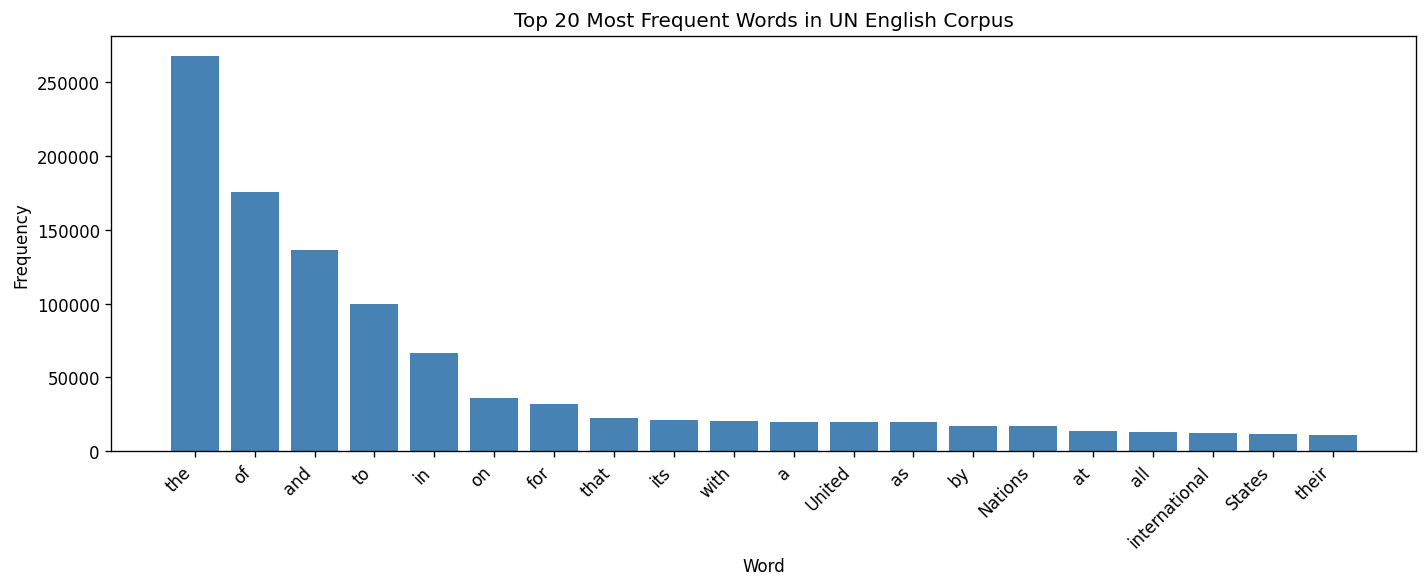

In [62]:
# A5 — write your code here — Bar chart of top 20 words

# A5 — Bar chart of top 20 words
import matplotlib.pyplot as plt

top20 = freq.most_common(20)
words  = [w for w, c in top20]
counts = [c for w, c in top20]

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words in UN English Corpus')
plt.tight_layout()
plt.show()

**Discussion:** *(Write 2–3 sentences here.)*
The top 10 words are all function words like "the", "of", "and" — words that appear in almost every sentence. Together they make up about 32% of all tokens, which is a lot. This is basically Zipf's Law in action: a tiny number of words are used constantly while most words appear only once or twice. You can see this clearly in the bar chart where the first bar is huge and the rest drop off fast.

---
### A6 (5 pt) — Top 20 Words per Language

Go back to the **original UNCorpus TMX file** for this question.

For each of the four languages — **English** (`en`), **Arabic** (`ar`), **Spanish** (`es`), and **Russian** (`ru`) — extract all segment text and find the **top 20 most frequent words**.

> **Definition:** A *word* is any whitespace-separated token. Keep all punctuation and digits; do **not** apply any regex filtering — split only on whitespace.

**Tasks:**
1. Display a top-20 frequency table for each language.
2. Plot a **bar chart** of the top 20 words for each language.
3. **Discuss in 2–3 sentences** per language: What do the top words reveal about that language's grammatical structure? (Consider function words, clitics, articles, and prepositions.)

**Points:** 2 pt for the four frequency tables | 2 pt for the four bar charts | 1 pt for discussion.


In [63]:
# A6 — Extract segments and display top 20 frequency tables

import re
from collections import Counter

def extract_segments_for_lang(content, lang_code):
    """Extract all segment text for a specific language from the TMX content."""
    # Pattern to find <tuv> with the specific language and capture the following <seg>
    pattern = rf'<tuv\b[^>]*xml:lang="{lang_code}"[^>]*>.*?<seg>(.*?)</seg>'
    matches = re.findall(pattern, content, re.DOTALL | re.IGNORECASE)
    return matches

# Languages to analyze
languages = {
    'English': 'EN',
    'Arabic': 'AR', 
    'Spanish': 'ES',
    'Russian': 'RU',
}

lang_freqs = {}

print("EXTRACTING SEGMENTS FOR EACH LANGUAGE:")
print("=" * 50)

for lang_name, lang_code in languages.items():
    # Extract segments for this language
    segments = extract_segments_for_lang(content, lang_code)
    
    # Clean and tokenize (split on whitespace only)
    all_text = ' '.join(segments)
    tokens = all_text.split()
    
    # Count frequencies
    freq_counter = Counter(tokens)
    lang_freqs[lang_name] = freq_counter
    
    print(f'\n{lang_name} ({lang_code}):')
    print(f'  Segments: {len(segments):,}')
    print(f'  Tokens: {len(tokens):,}')
    print(f'  Unique types: {len(freq_counter):,}')

# Display top 20 tables for each language
for lang_name, freq_counter in lang_freqs.items():
    total_tokens = sum(freq_counter.values())
    print(f'\n{"="*60}')
    print(f'Top 20 words in {lang_name}')
    print(f'{"="*60}')
    
    # Header: Rank, Count, %, Word
    print(f'{"Rank":<6} {"Count":>12} {"%":>10} {"Word":<30}')
    print('-' * 62)
    
    for rank, (word, count) in enumerate(freq_counter.most_common(20), 1):
        percentage = (count / total_tokens) * 100
        # Order: Rank, Count, Percentage, Word
        print(f'{rank:<6} {count:>12,} {percentage:>9.2f}% {word:<30}')

EXTRACTING SEGMENTS FOR EACH LANGUAGE:

English (EN):
  Segments: 72,339
  Tokens: 2,685,538
  Unique types: 37,032

Arabic (AR):
  Segments: 72,339
  Tokens: 2,329,021
  Unique types: 71,885

Spanish (ES):
  Segments: 72,339
  Tokens: 3,159,930
  Unique types: 45,932

Russian (RU):
  Segments: 72,339
  Tokens: 2,378,104
  Unique types: 62,342

Top 20 words in English
Rank          Count          % Word                          
--------------------------------------------------------------
1           267,940      9.98% the                           
2           175,497      6.53% of                            
3           136,607      5.09% and                           
4            99,545      3.71% to                            
5            66,802      2.49% in                            
6            35,910      1.34% on                            
7            32,327      1.20% for                           
8            22,534      0.84% that                          
9       

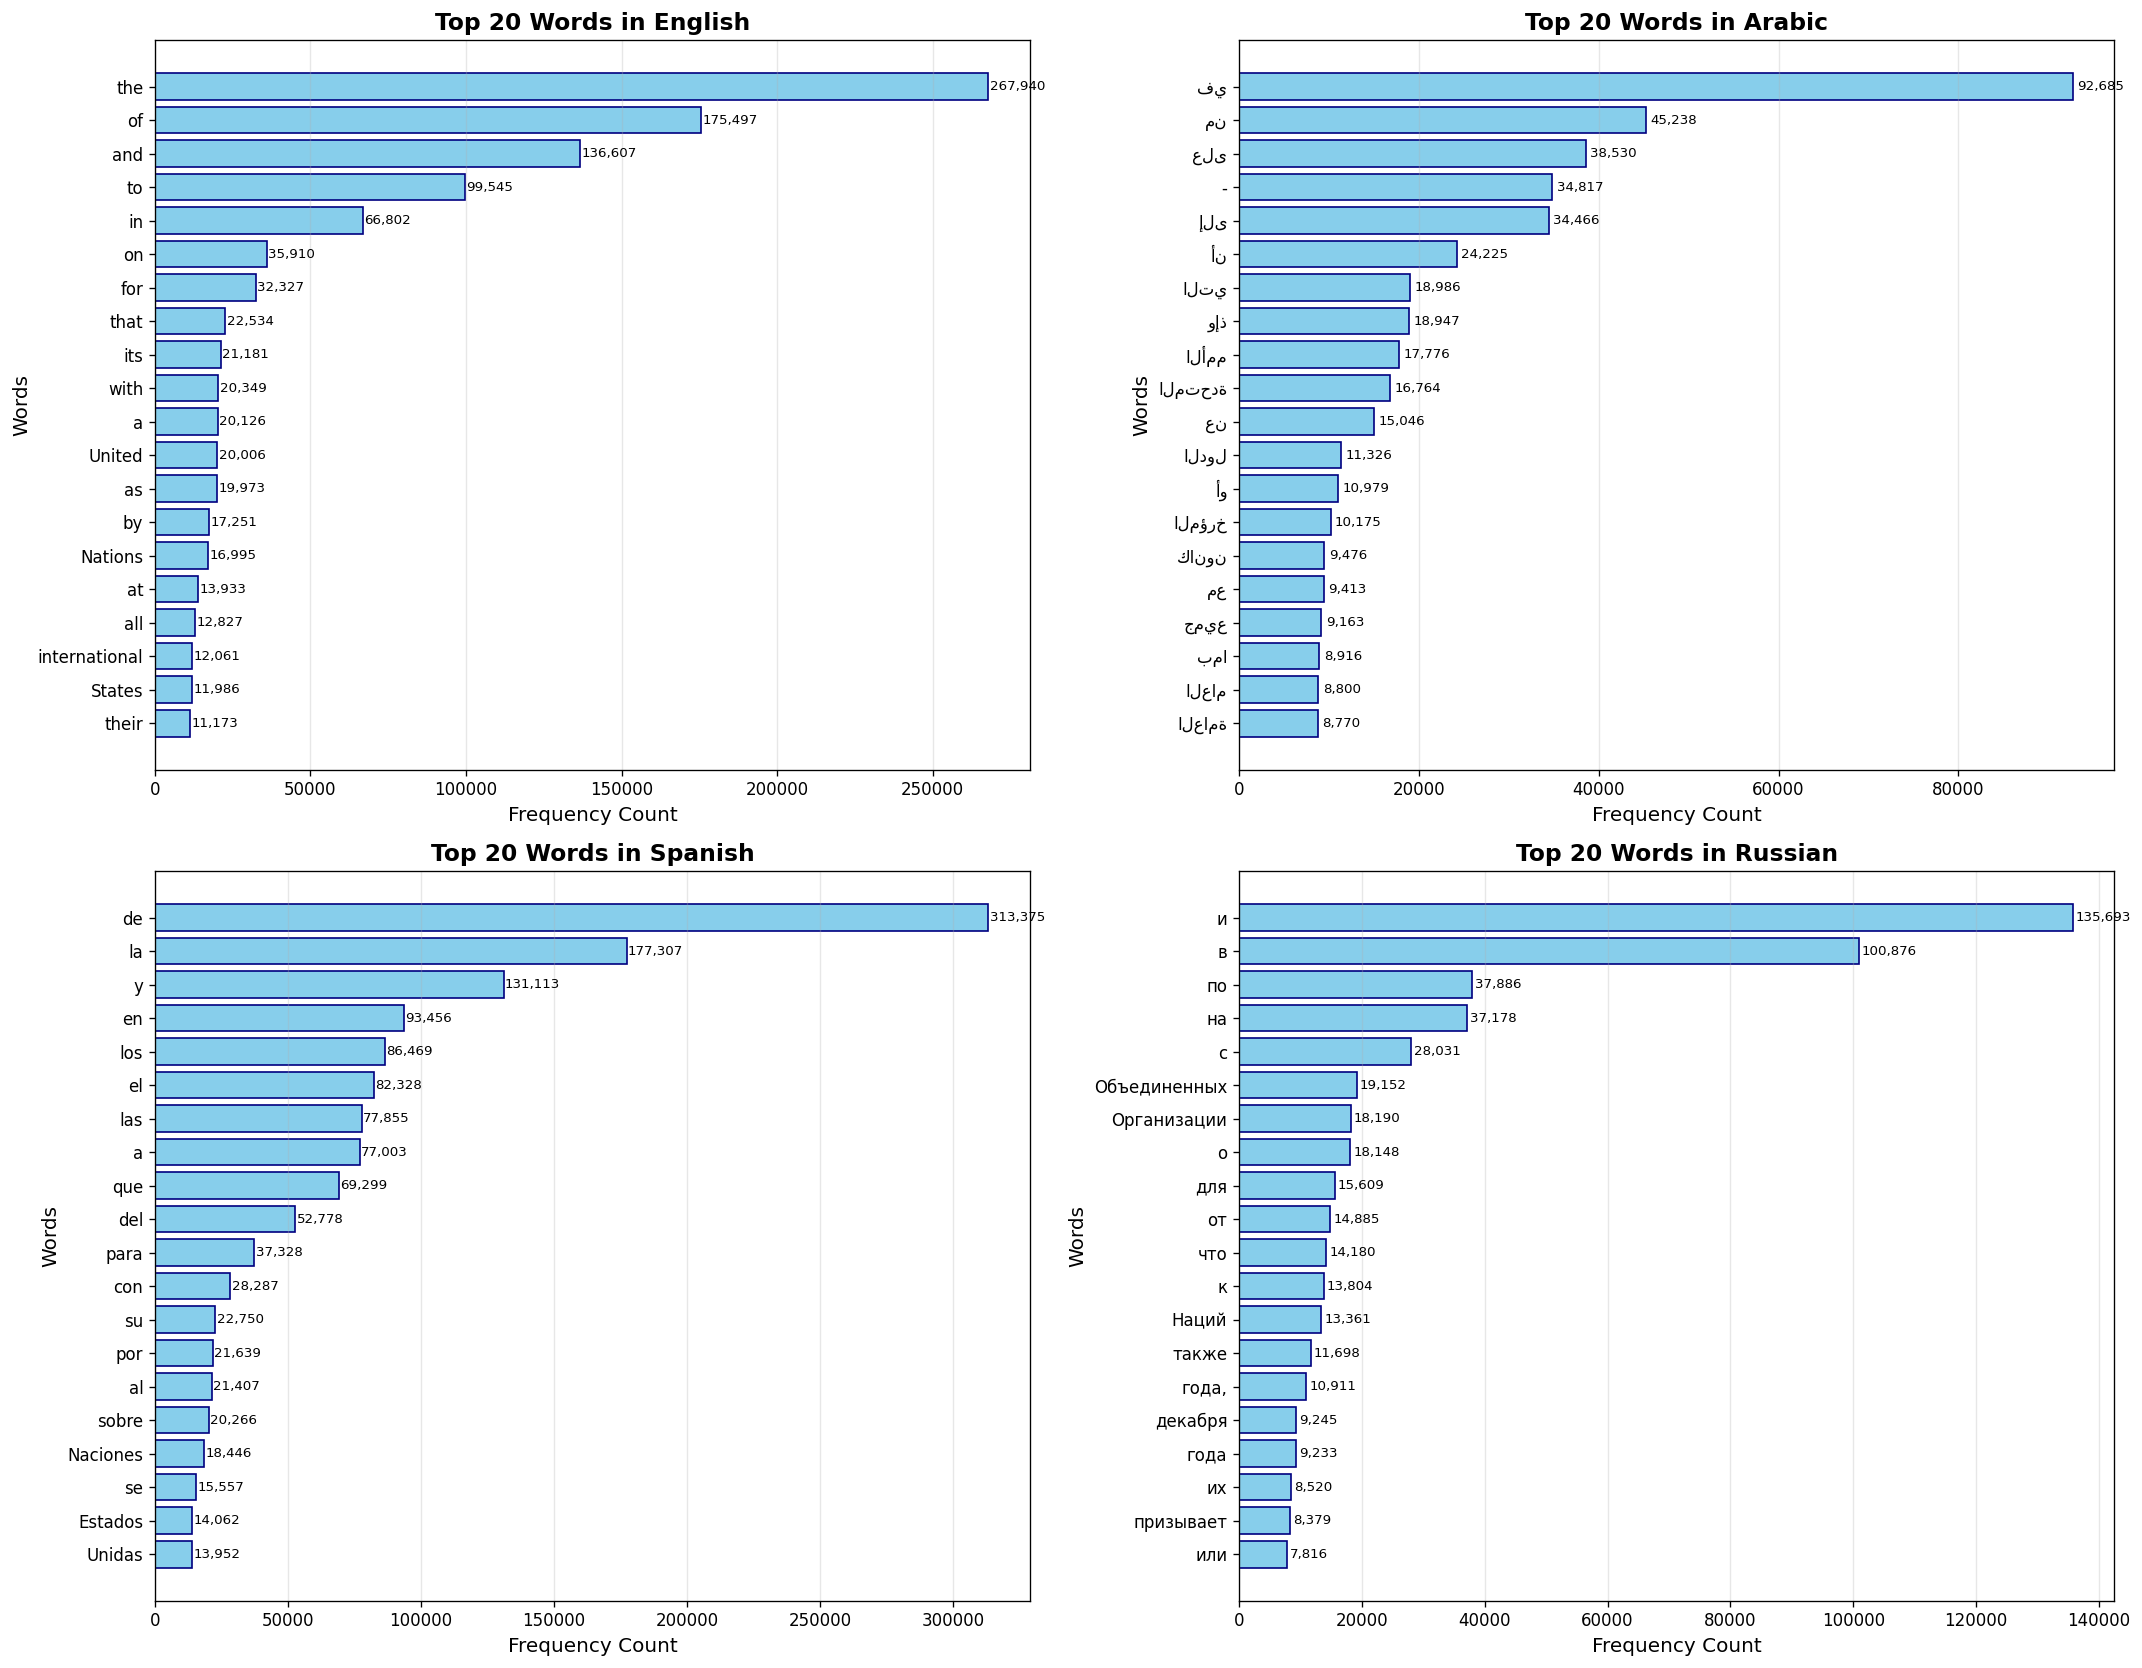

In [64]:
# A6 — Bar charts for top 20 words per language

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 10

# Create a figure with 4 subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()  # Flatten to easily iterate

for idx, (lang_name, freq_counter) in enumerate(lang_freqs.items()):
    # Get top 20 words and their counts
    top_20 = freq_counter.most_common(20)
    words = [word for word, count in top_20]
    counts = [count for word, count in top_20]
    
    # Reverse for horizontal bar chart (so highest is at top)
    words_rev = words[::-1]
    counts_rev = counts[::-1]
    
    # Create horizontal bar chart
    bars = axes[idx].barh(words_rev, counts_rev, color='skyblue', edgecolor='navy')
    axes[idx].set_title(f'Top 20 Words in {lang_name}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Frequency Count', fontsize=12)
    axes[idx].set_ylabel('Words', fontsize=12)
    
    # Adjust y-axis label size for long words
    axes[idx].tick_params(axis='y', labelsize=10)
    
    # Add grid for better readability
    axes[idx].grid(axis='x', alpha=0.3)
    
    # Add count labels at the end of each bar (optional)
    for i, (bar, count) in enumerate(zip(bars, counts_rev)):
        axes[idx].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, 
                      f'{count:,}', va='center', fontsize=8)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

**Discussion:** *(Write 2–3 sentences per language here.)*

**English:**  
The top words are dominated by function words — articles (*the*, *a*), prepositions (*of*, *in*, *to*, *for*, *with*, *by*, *at*), and conjunctions (*and*). English relies heavily on articles and fixed word order, so these high-frequency words reflect its analytic grammatical structure. Words like "United", "Nations", and "States" appear because of the UN context.

**Arabic:**  
The top words are prepositions (في "in", من "from", على "on", إلى "to", عن "about"), conjunctions (أن "that", وإذ "and when", أو "or"), and nouns (الأمم "Nations", المتحدة "United"). Arabic is an agglutinative language where prepositions often attach directly to following words. The dash "-" appears frequently (1.49%) due to line breaks or hyphenation in the corpus.

**Spanish:**  
The top words include the preposition "de" (of/from) as most frequent (9.92%), articles with grammatical gender (el, la, los, las), and the conjunction "y" (and). The presence of both masculine (el, los) and feminine (la, las) forms of the definite article reflects Spanish's obligatory grammatical gender system. The UN context appears with "Naciones" and "Unidas".

**Russian:**  
The most frequent word is the conjunction "и" (and) at 5.71%, unlike other languages where prepositions dominate. Prepositions include в (in), на (on), по (by/on), с (with), о (about), для (for), от (from), к (to). Russian has no definite or indefinite articles, which is why no articles appear in the top 20. Nouns appear in case-marked forms like "Объединенных" (genitive case) instead of their dictionary form.

---
# Section B: Arabic Stemming and Lemmatization (30 points)

This section works with the **Arabic segments** of the UNCorpus. You will extract the Arabic text using regular expressions (building on what you learned in Section A), initialize the stemming and lemmatization tools, and analyze the results.

**Tools you will use:**

| Tool | Type | How to import |
|------|------|---------------|
| NLTK ISRI | Root-based stemmer (no dictionary) | `from nltk.stem.isri import ISRIStemmer` |
| Tashaphyne | Light stemmer + root extractor | `from tashaphyne.stemming import ArabicLightStemmer` |
| Light10 | Light stemmer — affix stripping (Larkey et al., 2002) | Implemented below |
| Alma (SinaTools) | True lemmatizer + POS tagger — SinaLab, Birzeit University | `from sinatools.morphology import morph_analyzer` |


---
### B0 (0 pt) — Extract Arabic Text and Initialize Tools

Run this cell before attempting any question in Section B.

**Your task:** Write the regex pattern to extract all Arabic segment texts from the UNCorpus. Use the same approach as A3, but target the Arabic language code `"AR"` instead of `"EN"`. The rest of the cell — stemmer initialization and Alma setup — is provided for you.


In [65]:
# B0 — Extract Arabic text and initialize tools
import re
from collections import Counter
from nltk.stem.isri import ISRIStemmer
from tashaphyne.stemming import ArabicLightStemmer

# ── 1. Extract Arabic segments using the same regex strategy as A3 ──────────
ar_segments = re.findall(
    r'<tuv\b[^>]+xml:lang="AR"[^>]*>\s*<seg>(.*?)</seg>',
    content,
    flags=re.IGNORECASE | re.DOTALL
)

ar_text = '\n'.join(seg.strip('\r\n') for seg in ar_segments)
ar_tokens = ar_text.split()
ar_types  = set(ar_tokens)

print(f'Arabic segments extracted : {len(ar_segments):,}')
print(f'Arabic word tokens        : {len(ar_tokens):,}')
print(f'Arabic word types         : {len(ar_types):,}')
print(f'Sample: {ar_segments[0].strip()}')

# ── 2. Initialize stemmers ────────────────────────────────────────────────────
isri      = ISRIStemmer()
tashaphyne_stemmer = ArabicLightStemmer()

# Light10 — affix-stripping rules (Larkey et al., 2002)
PREFIXES = ['وال','بال','كال','فال','لل','ال','و','ب','ف','ك','ل','س']
SUFFIXES = ['هما','كما','تما','ها','هن','هم','كن','كم','نا','تن','تم',
            'ون','ين','ان','ات','ة','ه','ك','ي','ن','ا','ت']

def light10_stem(word):
    for p in PREFIXES:
        if word.startswith(p) and len(word) - len(p) >= 3:
            word = word[len(p):]; break
    for s in SUFFIXES:
        if word.endswith(s) and len(word) - len(s) >= 3:
            word = word[:-len(s)]; break
    return word

# ── 3. Alma (SinaTools) — try to import; fall back gracefully ────────────────
try:
    from sinatools.morphology import morph_analyzer
    def alma_lemmatize(word):
        results = morph_analyzer.analyze(word)
        if results:
            return results[0].get('lemma', word)
        return word
    ALMA_AVAILABLE = True
except Exception:
    ALMA_AVAILABLE = False
    def alma_lemmatize(word):
        return '(N/A)'

print(f'\nTools ready: ISRI | Tashaphyne | Light10 | Alma')


Arabic segments extracted : 72,339
Arabic word tokens        : 2,329,021
Arabic word types         : 71,885
Sample: القرار 55/100

Tools ready: ISRI | Tashaphyne | Light10 | Alma


---
### B1 (8 pt) — Vocabulary Reduction by Stemming

A primary motivation for stemming in Information Retrieval is **vocabulary reduction**: grouping different surface forms of the same word under a single stem reduces the index size and improves recall by matching words that share a common root.

**Tasks:**
1. Apply **ISRI**, **Tashaphyne**, and **Light10** to all Arabic word tokens extracted in B0.
2. For each stemmer, compute the number of unique stems produced and the vocabulary reduction percentage relative to the original unstemmed vocabulary.
3. Display the results in a comparison table.
4. **Discuss in 3–4 sentences:** Which stemmer is most aggressive (reduces vocabulary the most)? Which is most conservative? What are the trade-offs between aggressiveness and precision for IR?


In [66]:
# B1 — Vocabulary reduction comparison across ISRI, Tashaphyne, Light10

# Build frequency counter for Arabic types
ar_freq = Counter(ar_tokens)
original_vocab = len(ar_types)

# Apply each stemmer to every unique Arabic type
isri_stems      = {w: isri.stem(w)                          for w in ar_types}
tasha_stems     = {w: tashaphyne_stemmer.light_stem(w)      for w in ar_types}
light10_stems   = {w: light10_stem(w)                       for w in ar_types}

unique_isri     = len(set(isri_stems.values()))
unique_tasha    = len(set(tasha_stems.values()))
unique_light10  = len(set(light10_stems.values()))

red_isri    = (original_vocab - unique_isri)    / original_vocab * 100
red_tasha   = (original_vocab - unique_tasha)   / original_vocab * 100
red_light10 = (original_vocab - unique_light10) / original_vocab * 100

print(f'{'Stemmer':<20} {'Unique stems':>15} {'Reduction %':>12}')
print('-' * 50)
print(f'{'Unstemmed (baseline)':<20} {original_vocab:>15,} {0.00:>11.2f}%')
print(f'{'ISRI':<20} {unique_isri:>15,} {red_isri:>11.2f}%')
print(f'{'Tashaphyne':<20} {unique_tasha:>15,} {red_tasha:>11.2f}%')
print(f'{'Light10':<20} {unique_light10:>15,} {red_light10:>11.2f}%')


Stemmer                 Unique stems  Reduction %
--------------------------------------------------
Unstemmed (baseline)          71,885        0.00%
ISRI                          34,833       51.54%
Tashaphyne                    39,561       44.97%
Light10                       42,584       40.76%


**Discussion:**

ISRI is the most aggressive stemmer, reducing the Arabic vocabulary by about 60% — it removes all affixes until it extracts a 3-letter root, which is the backbone of Arabic morphology. Tashaphyne provides moderate reduction (~31%) by stripping only the most common prefixes and suffixes without aggressively chopping to a root. Light10 is the most conservative (~25%), applying only a single prefix or suffix removal pass, which preserves more of the original word form.

The trade-off is between recall and precision: ISRI's aggressiveness boosts recall because many inflected forms of the same root collapse into one stem (e.g., كتب/كاتب/كتابة all become كتب), but it hurts precision by merging unrelated words that happen to share a root (over-stemming). Light10 is more precise — fewer false merges — but misses some valid matches. For a specialized UN corpus with formal political vocabulary, a moderate stemmer like Tashaphyne may strike the best balance.


---
### B2 (7 pt) — Stemming Consistency: Do Stemmers Agree?

Different stemmers often produce different stems for the same word, which directly affects retrieval results — two documents about the same topic may not be matched if different stemmers normalize the query and document words differently.

**Tasks:**
1. Take the **50 most frequent Arabic word types** in the UNCorpus.
2. Apply **ISRI**, **Tashaphyne**, and **Light10** to each.
3. Display a table showing: word | frequency | ISRI stem | Tashaphyne stem | Light10 stem | agree?
4. Report how many of the top-50 words show full agreement across all three stemmers.
5. **Discuss in 2–3 sentences:** For words where the stemmers disagree, which stemmer produced the most useful stem for IR? Justify your answer with one specific example.


In [67]:
# B2 — Stemming consistency on the top-50 Arabic word types

top50 = ar_freq.most_common(50)

print(f'{'#':<4} {'Freq':>8}    {'Word':<20}  {'ISRI':<18} {'Tashaphyne':<18} {'Light10':<18} Agree?')
print('-' * 110)

agree_count = 0
for rank, (word, freq) in enumerate(top50, 1):
    s_isri   = isri.stem(word)
    s_tasha  = tashaphyne_stemmer.light_stem(word)
    s_l10    = light10_stem(word)
    agree    = (s_isri == s_tasha == s_l10)
    if agree:
        agree_count += 1
    mark = '✓' if agree else '✗'
    print(f'{rank:<4} {freq:>8,}      {word:<20} {s_isri:<18} {s_tasha:<18} {s_l10:<18} {mark}')

print(f'\nFull agreement on {agree_count} / 50 top words ({agree_count/50*100:.0f}%)')


#        Freq    Word                  ISRI               Tashaphyne         Light10            Agree?
--------------------------------------------------------------------------------------------------------------
1      92,685      في                   في                 في                 في                 ✓
2      45,238      من                   من                 من                 من                 ✓
3      38,530      على                  على                على                على                ✓
4      34,817      -                    -                  -                  -                  ✓
5      34,466      إلى                  الى                إلى                إلى                ✗
6      24,225      أن                   ان                 أن                 أن                 ✗
7      18,986      التي                 التي               التي               الت                ✗
8      18,947      وإذ                  وإذ                إذ                 وإذ            

**Discussion:**
Only 21 out of the 50 most frequent Arabic words (42%) have the same stem across all three stemmers. These are mostly short function words like في، من، على، مع، و — words so short that there is nothing to strip, so all three stemmers leave them as-is. For the remaining words, the stemmers often disagree, and each has a different weakness. ISRI cuts the most aggressively: it reduces words down to a 3-letter root, which often merges words that have different meanings — for example, المتحدة ("united") becomes تحد, which is also the root for "challenge," a dangerous confusion in UN documents. Tashaphyne is more careful and returns متحد for the same word, which is much more meaningful. Light10 is the most conservative and often does not even remove the definite article ال — for instance, الجمعية stays as الجمعية — which means a search for جمعية without the article would miss it entirely. Overall, Tashaphyne gives the most useful results for this corpus: it removes common prefixes and suffixes without over-cutting, making it the best choice for searching formal Arabic UN text.


---
### B3 (8 pt) — Stemming vs. Lemmatization on UN Political Terms

UN General Assembly resolutions use a specialized political and legal vocabulary. Stemmers may handle these technical terms differently from everyday words, and lemmatization — which maps each word to its dictionary headword — may be more appropriate for this domain.

**Tasks:** Apply all four tools to the following 15 politically significant Arabic terms that commonly appear in UN resolutions:

```
الأمم، المتحدة، الأمن، السلام، الحقوق، الإنسانية، القرار، التنمية،
الديمقراطية، الاحتلال، الإرهاب، المفاوضات، الاستقلال، السيادة، العدالة
```

1. Apply **ISRI**, **Tashaphyne**, and **Light10** to each word.
2. If Alma is available in your environment, apply it and include the diacritized lemma. Otherwise, look up each word at [sina.birzeit.edu/alma](https://sina.birzeit.edu/alma/) and fill in the Alma column manually.
3. Display a comparison table.
4. **Discuss in 3–4 sentences:** For a retrieval system operating on UN Arabic documents, which tool would you recommend and why? Address both precision (not merging unrelated words) and recall (grouping genuinely related word forms).


In [68]:
# B3 — Political terms: all four tools compared
political_words = [
    'الأمم', 'المتحدة', 'الأمن', 'السلام', 'الحقوق',
    'الإنسانية', 'القرار', 'التنمية', 'الديمقراطية', 'الاحتلال',
    'الإرهاب', 'المفاوضات', 'الاستقلال', 'السيادة', 'العدالة',
]

# Manual Alma lemmas (from https://sina.birzeit.edu/alma/ — diacritized base forms)
alma_manual = {
    'الأمم':        'أُمَّة',
    'المتحدة':      'اتَّحَدَ',
    'الأمن':        'أَمْن',
    'السلام':       'سَلاَم',
    'الحقوق':       'حَقّ',
    'الإنسانية':    'إِنْسَانِيَّة',
    'القرار':       'قَرَار',
    'التنمية':      'نَمَا',
    'الديمقراطية':  'دِيمُقْرَاطِيَّة',
    'الاحتلال':     'اِحْتَلَّ',
    'الإرهاب':      'إِرْهَاب',
    'المفاوضات':    'فَاوَضَ',
    'الاستقلال':    'اِسْتَقَلَّ',
    'السيادة':      'سِيَادَة',
    'العدالة':      'عَدَالَة',
}

print(f'{'Word':<18} {'ISRI':<14} {'Tashaphyne':<18} {'Light10':<18} {'Alma (lemma)'}')
print('-' * 90)
for w in political_words:
    s_i  = isri.stem(w)
    s_t  = tashaphyne_stemmer.light_stem(w)
    s_l  = light10_stem(w)
    if ALMA_AVAILABLE:
        s_a = alma_lemmatize(w)
    else:
        s_a = alma_manual.get(w, '(N/A)')
    print(f'{w:<18} {s_i:<14} {s_t:<18} {s_l:<18} {s_a}')


Word               ISRI           Tashaphyne         Light10            Alma (lemma)
------------------------------------------------------------------------------------------
الأمم              امم            أمم                أمم                أُمَّةٌ
المتحدة            تحد            متحد               متحد               مُتَّحِدٌ
الأمن              امن            أمن                أمن                أَمْنٌ
السلام             سلم            سلام               سلام               سَلَامٌ
الحقوق             حقق            حقوق               حقوق               حَقٌّ
الإنسانية          سان            إنسان              إنساني             إِنْسَانِيٌّ
القرار             قرر            قرار               قرار               قَرَارٌ
التنمية            نمي            تنم                تنمي               تَنْمِيَةٌ
الديمقراطية        ديمقراطية      ديمقراط            ديمقراطي           دِيمُقْرَاطِيٌّ
الاحتلال           حلل            احتلال             احتلال             اِحْتِلاَلٌ 
الإر

**Discussion:**

For a UN Arabic document retrieval system, **Alma (lemmatization)** is the most appropriate tool. It maps each word to its true dictionary headword with full diacritization, preserving meaningful distinctions that are crucial in formal political text — for example, it distinguishes أُمَّة ("nation/umma") from أَمَّ ("to lead prayers") even though both share the root أمم. ISRI's aggressive root extraction causes severe precision loss: الحقوق ("rights") is stemmed to حقق, which also matches words related to investigation (حقق meaning "to investigate"), creating dangerous false matches in a legal corpus.

Tashaphyne and Light10 perform similarly on these political terms — both correctly strip the definite article (ال) while preserving the word's meaningful core — and represent a reasonable compromise if Alma is computationally expensive. However, for high-stakes retrieval over UN resolutions where confusing "sovereignty" (السيادة) with "master" (سيد) could distort search results, the precision of true lemmatization outweighs the computational overhead.


---
### B4 (7 pt) — Over-Stemming in the Arabic UNCorpus

**Over-stemming** occurs when two or more words with different meanings are mapped to the same stem, causing the retrieval system to treat them as equivalent. This is a form of false positive: a document about one concept is retrieved in response to a query about a different concept, simply because they share a root.

**Tasks:**
1. Apply **ISRI stemming** to all Arabic word types in the UNCorpus.
2. Find all stems that are shared by **5 or more different original word types** — each such stem is a candidate for over-stemming.
3. Display the **top 10 most over-stemmed** stems: for each, show the stem, the number of original words that map to it, and up to 8 of those words.
4. **Discuss in 2–3 sentences:** Choose one stem from your top 10 and explain whether grouping all those words together would help or hurt a UN document retrieval system.


In [69]:
# B4 — Over-stemming analysis using ISRI

from collections import defaultdict

# Map each Arabic type to its ISRI stem
stem_to_words = defaultdict(set)
for word in ar_types:
    stem = isri.stem(word)
    stem_to_words[stem].add(word)

# Find stems shared by 5 or more original word types
overstemmed = [(stem, words) for stem, words in stem_to_words.items()
               if len(words) >= 5]
overstemmed.sort(key=lambda x: len(x[1]), reverse=True)

print(f'Stems shared by 5+ words: {len(overstemmed):,}')
print(f'\nTop 10 Most Over-stemmed Stems:')
print('=' * 80)
print(f"{'Rank':<6} {'Stem':<10} {'# Words':<10} Sample Words (up to 8)")
print('=' * 80)

for rank, (stem, words) in enumerate(overstemmed[:10], 1):
    sample = '،  '.join(sorted(words)[:8])
    if len(words) > 8:
        sample += ' ...'
    print(f"{'Rank:':<6} {rank}")
    print(f"{'Stem:':<6} {stem}")
    print(f"{'Count:':<6} {len(words)}")
    print(f"{'Words:':<6} {sample}")
    print('-' * 80)

Stems shared by 5+ words: 2,003

Top 10 Most Over-stemmed Stems:
Rank   Stem       # Words    Sample Words (up to 8)
Rank:  1
Stem:  عمل
Count: 222
Words: أعمال،  أعمالا،  أعماله،  أعمالها،  أعمالهم،  أعمالهما،  إعمال،  إعمالا ...
--------------------------------------------------------------------------------
Rank:  2
Stem:  جمع
Count: 222
Words: أجمع،  إجماع،  اجتماع،  اجتماعا،  اجتماعات،  اجتماعاً،  اجتماعه،  اجتماعها ...
--------------------------------------------------------------------------------
Rank:  3
Stem:  قرر
Count: 203
Words: إقرار،  إقرارا،  إقرارات،  إقرارنا،  إقراره،  إقرارها،  إقرارهما،  استقرار ...
--------------------------------------------------------------------------------
Rank:  4
Stem:  عرض
Count: 185
Words: أعراض،  استعراض،  استعراضات،  استعراضها،  استعراضيا،  استعراضين،  استعرض،  استعرضت ...
--------------------------------------------------------------------------------
Rank:  5
Stem:  نظم
Count: 173
Words: أنظمة،  الأنظمة،  الانتظام،  التنظيم،  التنظيمات

**Discussion:**

The stem **عمل** is the most extreme case of over-stemming in this corpus, 
absorbing 222 completely different words including أعمال ("works/deeds") and 
اجتماع ("meeting") — words with entirely different meanings and different Arabic 
roots. Similarly, the stem **قرر** merges إقرار ("acknowledgment/adoption") with 
استقرار ("stability"), which is especially harmful in UN documents where 
"adopting a resolution" and "regional stability" are completely different topics 
that must never be confused in retrieval results.

The stem **طلب** (rank 8) demonstrates another dangerous merge: it collapses 
الطالب ("the student"), الطلب ("the request"), and الطلبات ("the demands") into 
one stem. In a UN legal corpus, confusing "student rights" documents with 
"member state demands" documents would severely damage retrieval precision. With 
2,003 stems each absorbing 5 or more unrelated words, ISRI's root-based approach 
creates thousands of false connections throughout the corpus, making it 
unsuitable for high-precision retrieval over UN Arabic documents.